In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_csv('gold_loan.csv')
df

,customer_id,age,gender,state,occupation,emp_years,monthly_income,active_loans,past_defaults,cibil_score,...,ltv_ratio,interest_rate_pct,tenure_months,emi_inr,income_to_emi,total_debt_burden,loan_year,loan_month,loan_quarter,default_status
0,GLC000000,29,Male,Kerala,Small Business,4,33895,3,0,486,...,70.8593,23.49,6,16278.61,2.0822,1.4408,2023,4,2,0
1,GLC000001,60,Female,Kerala,Professional,5,243033,0,0,840,...,83.9914,13.20,6,50721.90,4.7915,0.2087,2024,6,2,0
2,GLC000002,61,Female,Kerala,Salaried,1,78196,0,1,639,...,86.8703,20.02,12,25299.92,3.0908,0.3235,2024,10,4,0
3,GLC000003,39,Male,Maharashtra,Small Business,7,31117,0,2,474,...,72.0349,23.56,18,31105.57,1.0004,0.9996,2023,3,1,0
4,GLC000004,37,Male,Kerala,Daily Wage,0,11453,2,2,300,...,68.6362,27.45,21,40997.99,0.2794,7.1593,2024,6,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,GLC017995,32,Male,Rajasthan,Salaried,9,121528,1,0,754,...,57.8639,11.88,6,64855.74,1.8738,0.5337,2022,6,2,0
17996,GLC017996,32,Male,Maharashtra,Salaried,10,51170,2,1,644,...,71.5363,20.11,12,31547.33,1.6220,1.2330,2024,7,3,0
17997,GLC017997,37,Male,Tamil Nadu,Salaried,9,74848,1,0,846,...,72.4493,13.11,18,23322.72,3.2092,0.3116,2023,6,2,0
17998,GLC017998,27,Male,Telangana,Salaried,9,63455,1,1,521,...,69.8215,22.97,9,79513.75,0.7980,1.2531,2023,11,4,0


In [5]:
print("Data Details")
print("_" * 50)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("_" * 50)
print(f"Missing values:\n{df.isnull().sum()}")

Data Details
__________________________________________________
Number of rows: 18000
Number of columns: 27
Duplicate rows: 0
__________________________________________________
Missing values:
customer_id          0
age                  0
gender               0
state                0
occupation           0
emp_years            0
monthly_income       0
active_loans         0
past_defaults        0
cibil_score          0
lender_type          0
gold_type            0
gold_weight_g        0
gold_purity_kt       0
market_value_inr     0
recoverable_value    0
loan_amount_inr      0
ltv_ratio            0
interest_rate_pct    0
tenure_months        0
emi_inr              0
income_to_emi        0
total_debt_burden    0
loan_year            0
loan_month           0
loan_quarter         0
default_status       0
dtype: int64


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        18000 non-null  str    
 1   age                18000 non-null  int64  
 2   gender             18000 non-null  str    
 3   state              18000 non-null  str    
 4   occupation         18000 non-null  str    
 5   emp_years          18000 non-null  int64  
 6   monthly_income     18000 non-null  int64  
 7   active_loans       18000 non-null  int64  
 8   past_defaults      18000 non-null  int64  
 9   cibil_score        18000 non-null  int64  
 10  lender_type        18000 non-null  str    
 11  gold_type          18000 non-null  str    
 12  gold_weight_g      18000 non-null  float64
 13  gold_purity_kt     18000 non-null  int64  
 14  market_value_inr   18000 non-null  float64
 15  recoverable_value  18000 non-null  float64
 16  loan_amount_inr    18000 non-null

# Statistical Summary

In [7]:
df.describe()

,age,emp_years,monthly_income,active_loans,past_defaults,cibil_score,gold_weight_g,gold_purity_kt,market_value_inr,recoverable_value,...,ltv_ratio,interest_rate_pct,tenure_months,emi_inr,income_to_emi,total_debt_burden,loan_year,loan_month,loan_quarter,default_status
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,1.800000e+04,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,41.590556,5.141944,69310.620722,1.271000,0.728167,533.875556,101.936466,21.479222,5.700398e+05,4.796947e+05,...,76.728613,21.591311,12.809833,48080.248198,3.213982,2.022624,2023.001778,6.535167,2.515500,0.351056
std,10.632998,3.784887,60929.883347,1.186252,0.928613,179.942048,56.303181,1.964096,3.216702e+05,2.731078e+05,...,8.788499,5.873890,5.498304,41694.648666,6.593890,2.919922,0.819031,3.448507,1.120836,0.477314
min,21.000000,0.000000,8000.000000,0.000000,0.000000,300.000000,5.010000,18.000000,2.277273e+04,1.786968e+04,...,55.000000,9.010000,3.000000,1038.620000,0.074800,0.006100,2022.000000,1.000000,1.000000,0.000000
25%,34.000000,2.000000,27029.000000,0.000000,0.000000,368.000000,53.180000,20.000000,2.952487e+05,2.478227e+05,...,69.972350,16.820000,9.000000,20165.910000,0.651175,0.408300,2022.000000,4.000000,2.000000,0.000000
50%,42.000000,4.000000,50837.500000,1.000000,0.000000,520.000000,101.690000,22.000000,5.624067e+05,4.711823e+05,...,75.000000,23.080000,12.000000,38677.940000,1.342750,0.999850,2023.000000,7.000000,3.000000,0.000000
75%,49.000000,7.000000,88889.000000,2.000000,1.000000,678.000000,150.380000,22.000000,8.319909e+05,6.966247e+05,...,84.945650,26.540000,18.000000,62777.402500,3.072550,2.345700,2024.000000,10.000000,4.000000,1.000000
max,70.000000,19.000000,319934.000000,4.000000,3.000000,900.000000,199.980000,24.000000,1.326239e+06,1.273399e+06,...,90.000000,30.000000,24.000000,403746.720000,164.987600,32.852200,2024.000000,12.000000,4.000000,1.000000


In [8]:
df.columns.unique()

Index(['customer_id', 'age', 'gender', 'state', 'occupation', 'emp_years',
       'monthly_income', 'active_loans', 'past_defaults', 'cibil_score',
       'lender_type', 'gold_type', 'gold_weight_g', 'gold_purity_kt',
       'market_value_inr', 'recoverable_value', 'loan_amount_inr', 'ltv_ratio',
       'interest_rate_pct', 'tenure_months', 'emi_inr', 'income_to_emi',
       'total_debt_burden', 'loan_year', 'loan_month', 'loan_quarter',
       'default_status'],
      dtype='str')

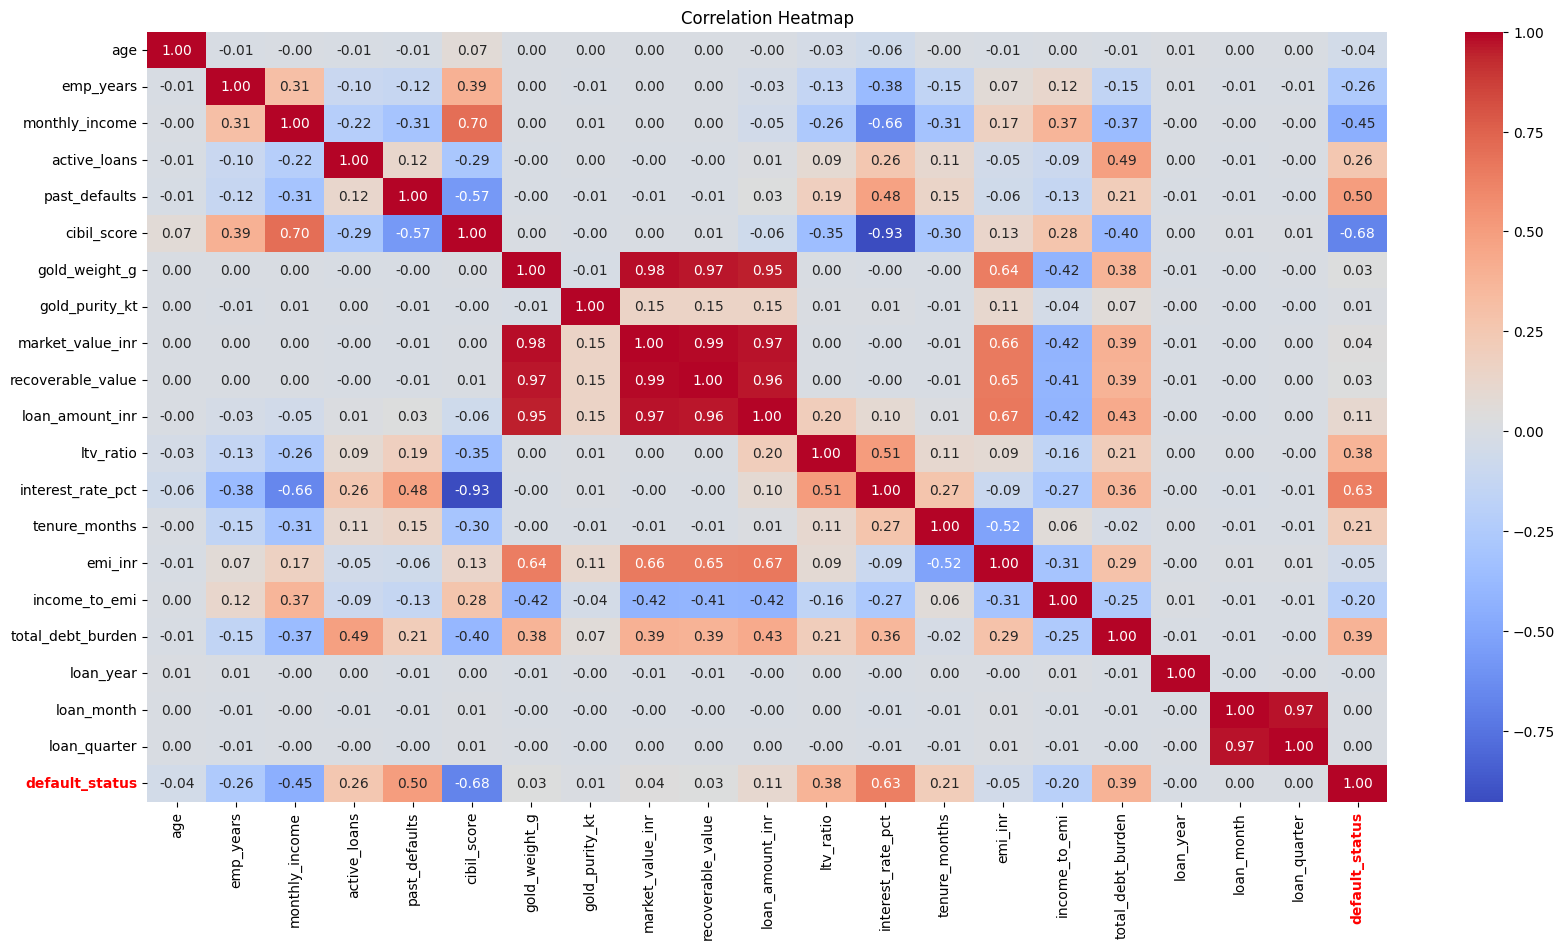

In [9]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(20, 10))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)


for label in ax.get_xticklabels():
    if label.get_text() == "default_status":
        label.set_color("red")
        label.set_fontweight("bold")

for label in ax.get_yticklabels():
    if label.get_text() == "default_status":
        label.set_color("red")
        label.set_fontweight("bold")

plt.title("Correlation Heatmap")
plt.show()

##### + Positive correlation

+past default
+active loan
+total debt burden
+intrest rate 
+ltv ratio
+emi

##### - Negative correlation

-cibilscore
-monthlyincome
-emp_years
-income to emi

##### / Moderate correlation

/ loan amount 
/ tenure months 



# Model Training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score



In [11]:
# Risk map is hardcoded by YOU, not learned from data
occupation_risk_map = {
    'Professional': 1,
    'Salaried':     2,
    'Small Business': 3,
    'Farmer':       4,
    'Daily Wage':   5
}
df['occupation_encoded'] = df['occupation'].map(occupation_risk_map)

In [12]:
print(df['occupation_encoded'].value_counts())
print(df['occupation'].value_counts())

occupation_encoded
2    4984
3    4391
4    3623
5    2879
1    2123
Name: count, dtype: int64
occupation
Salaried          4984
Small Business    4391
Farmer            3623
Daily Wage        2879
Professional      2123
Name: count, dtype: int64


In [13]:
df

,customer_id,age,gender,state,occupation,emp_years,monthly_income,active_loans,past_defaults,cibil_score,...,interest_rate_pct,tenure_months,emi_inr,income_to_emi,total_debt_burden,loan_year,loan_month,loan_quarter,default_status,occupation_encoded
0,GLC000000,29,Male,Kerala,Small Business,4,33895,3,0,486,...,23.49,6,16278.61,2.0822,1.4408,2023,4,2,0,3
1,GLC000001,60,Female,Kerala,Professional,5,243033,0,0,840,...,13.20,6,50721.90,4.7915,0.2087,2024,6,2,0,1
2,GLC000002,61,Female,Kerala,Salaried,1,78196,0,1,639,...,20.02,12,25299.92,3.0908,0.3235,2024,10,4,0,2
3,GLC000003,39,Male,Maharashtra,Small Business,7,31117,0,2,474,...,23.56,18,31105.57,1.0004,0.9996,2023,3,1,0,3
4,GLC000004,37,Male,Kerala,Daily Wage,0,11453,2,2,300,...,27.45,21,40997.99,0.2794,7.1593,2024,6,2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17995,GLC017995,32,Male,Rajasthan,Salaried,9,121528,1,0,754,...,11.88,6,64855.74,1.8738,0.5337,2022,6,2,0,2
17996,GLC017996,32,Male,Maharashtra,Salaried,10,51170,2,1,644,...,20.11,12,31547.33,1.6220,1.2330,2024,7,3,0,2
17997,GLC017997,37,Male,Tamil Nadu,Salaried,9,74848,1,0,846,...,13.11,18,23322.72,3.2092,0.3116,2023,6,2,0,2
17998,GLC017998,27,Male,Telangana,Salaried,9,63455,1,1,521,...,22.97,9,79513.75,0.7980,1.2531,2023,11,4,0,2


In [14]:
X = df[['occupation_encoded','past_defaults', 'active_loans', 'total_debt_burden', 'interest_rate_pct',
        'ltv_ratio', 'emi_inr', 'cibil_score', 'monthly_income',
        'emp_years', 'income_to_emi', 'loan_amount_inr', 'tenure_months']]

Y = df['default_status']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)

In [16]:
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Logistic Regression

In [17]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      2336
           1       0.78      0.90      0.84      1264

    accuracy                           0.88      3600
   macro avg       0.86      0.88      0.87      3600
weighted avg       0.89      0.88      0.88      3600

ROC-AUC: 0.9518129822698109


# XG Boost Classifier

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

neg, pos = y_train.value_counts()

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=neg/pos
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb  = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print()

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.93      0.87      0.90      2336
           1       0.79      0.89      0.84      1264

    accuracy                           0.88      3600
   macro avg       0.86      0.88      0.87      3600
weighted avg       0.88      0.88      0.88      3600

ROC-AUC: 0.9508775684931506



In [19]:
lr_acc= roc_auc_score(y_test, y_proba_lr)
print(f"Logistic Regression ROC-AUC :{lr_acc * 100:.2f} %")

xgb_acc = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC-AUC :{xgb_acc * 100:.2f} %")

Logistic Regression ROC-AUC :95.18 %
XGBoost ROC-AUC :95.09 %


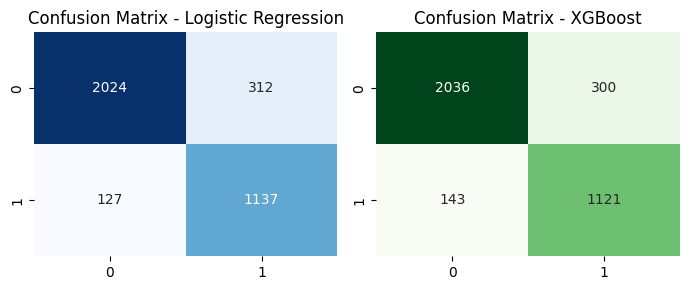

In [20]:
confusion_lr = confusion_matrix(y_test, y_pred_lr)
confusion_xgb = confusion_matrix(y_test, y_pred_xgb)    
plt.figure(figsize=(7,3))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix - Logistic Regression") 

plt.subplot(1, 2, 2)
sns.heatmap(confusion_xgb, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - XGBoost") 

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred_lr, label='Logistic Regression', marker='s', linestyle='--', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Default Status')
plt.title('Logistic Regression Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_test.values, label='Actual', marker='o', linestyle='-', alpha=0.7)
plt.plot(y_pred_xgb, label='XGBoost', marker='s', linestyle='--', alpha=0.7)
plt.xlabel('Sample Index')
plt.ylabel('Default Status')
plt.title('XGBoost Predictions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
import joblib
joblib.dump(lr, 'ML_model.pkl')
print("Model saved as: ML_model.pkl")

Model saved as: ML_model.pkl
